<a href="https://colab.research.google.com/github/krupa026/CEBS/blob/main/brainTumourDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving brain dataset.zip to brain dataset.zip


In [ ]:
import zipfile

zip_path = "brain dataset.zip"  # replace with your filename
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("Brain Dataset")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import shutil
import glob

In [ ]:
# total 4 classes are there in the dataset
ROOT_DIR = "/content/Brain Dataset/brain dataset"
number_of_images = {}

for dir in os.listdir(ROOT_DIR):
  number_of_images[dir] = len(os.listdir(os.path.join(ROOT_DIR, dir)))
number_of_images.items()

dict_items([('notumor', 1400), ('tumour', 4200)])

70% for training
15% for validation
15% for testing


In [ ]:
#create train folder
# if not os.path.exists("./train"):
#   os.mkdir("./train")

#   for dir in os.listdir(ROOT_DIR):
#     os.makedirs("./train/"+ dir)
#     for img in np.random.choice(
#     a=os.listdir(os.path.join(ROOT_DIR, dir)),
#     size=min(len(os.listdir(os.path.join(ROOT_DIR, dir))),
#              math.floor(70/100 * number_of_images[dir]) - 5),
#     replace=False):

#       O = os.path.join(ROOT_DIR, dir, img)#path
#       D = os.path.join("./train", dir)
#       os.remove(O)
# else:
#   print("the folder exists")


In [ ]:
def dataFolder(p,split):
  #create train folder
  if not os.path.exists("./"+p):
    os.mkdir("./"+p)

    for dir in os.listdir(ROOT_DIR):
      os.makedirs("./"+p+"/"+ dir)
      for img in np.random.choice(
      a=os.listdir(os.path.join(ROOT_DIR, dir)),
      size=min(len(os.listdir(os.path.join(ROOT_DIR, dir))),
              math.floor(split * number_of_images[dir]) - 5),
      replace=False):

        O = os.path.join(ROOT_DIR, dir, img)#path
        D = os.path.join("./"+p, dir)
        shutil.copy(O,D)
        os.remove(O)
  else:
    print(f"{p} folder exists")

In [ ]:
dataFolder("train",0.7)

In [ ]:
dataFolder("val",0.15)

In [ ]:
dataFolder("test",0.15)

In [ ]:
# model building
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#cnn model
model = Sequential()

model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu',input_shape=(224,224,3)))

model.add(Conv2D(filters=36, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(rate = 0.25))

model.add(Flatten())
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dropout(rate = 0.25))
model.add(Dense(units = 1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 36)   │         5,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 36)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,638,245 (21.51 MB)

 Trainable params: 5,638,245 (21.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#data generator
def preprocessingImages1(path):
  # input : path
  # output : preprocessed images
  image_data = ImageDataGenerator(zoom_range=0.2, shear_range=0.2, rescale=1/255, horizontal_flip=True)
  image = image_data.flow_from_directory(directory=path, target_size=(224,224), batch_size=32, class_mode='binary')
  return image


In [ ]:
path = "/content/train"
train_data = preprocessingImages1(path)

Found 3909 images belonging to 2 classes.


In [ ]:
def preprocessingImages2(path):
  # input : path
  # output : preprocessed images
  image_data = ImageDataGenerator( rescale=1/255)
  image = image_data.flow_from_directory(directory=path, target_size=(224,224), batch_size=32, class_mode='binary')
  return image

In [ ]:
path = "/content/test"
test_data = preprocessingImages2(path)

Found 830 images belonging to 2 classes.


In [ ]:
path = "/content/val"
val_data = preprocessingImages2(path)

Found 830 images belonging to 2 classes.


In [ ]:
#early stopping and model check point
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

es = EarlyStopping(monitor="val_accuracy",min_delta = 0.01, patience= 5, verbose= 1, mode= 'auto')

mc = ModelCheckpoint(monitor="val_accuracy",filepath="./bestmodel.h5",verbose=1,save_best_only= True, mode= 'auto')

cd = [es,mc]

In [ ]:
#model training
hs = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    epochs=30,
    verbose=1,
    validation_data=val_data,
    validation_steps=val_data.samples // val_data.batch_size,
    callbacks=cd

)

Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9115 - loss: 0.2339
Epoch 1: val_accuracy improved from 0.92773 to 0.95875, saving model to ./bestmodel.h5



Epoch 1: finished saving model to ./bestmodel.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 59s 480ms/step - accuracy: 0.9350 - loss: 0.1839 - val_accuracy: 0.9588 - val_loss: 0.1278
Epoch 2/30
  1/122 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.9375 - loss: 0.1238

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.95875
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9375 - loss: 0.1238 - val_accuracy: 0.9488 - val_loss: 0.1389
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9429 - loss: 0.1591
Epoch 3: val_accuracy improved from 0.95875 to 0.96500, saving model to ./bestmodel.h5



Epoch 3: finished saving model to ./bestmodel.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 51s 421ms/step - accuracy: 0.9505 - loss: 0.1403 - val_accuracy: 0.9650 - val_loss: 0.1064
Epoch 4/30
  1/122 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9688 - loss: 0.0383
Epoch 4: val_accuracy did not improve from 0.96500
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9688 - loss: 0.0383 - val_accuracy: 0.9588 - val_loss: 0.1219
Epoch 4: early stopping


In [ ]:
# Model graphical interpretation
h = hs.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

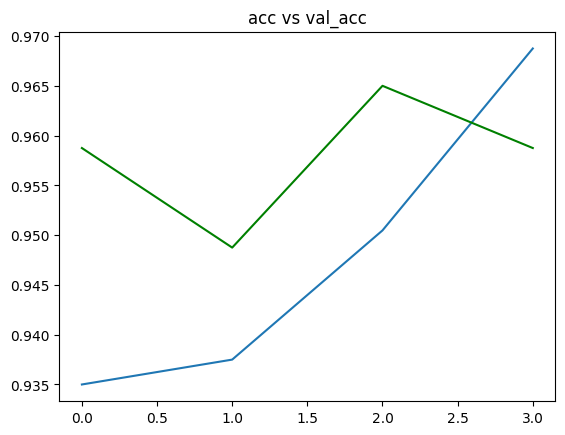

In [ ]:
import matplotlib.pyplot as plt
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c="green")

plt.title("acc vs val_acc")
plt.show()

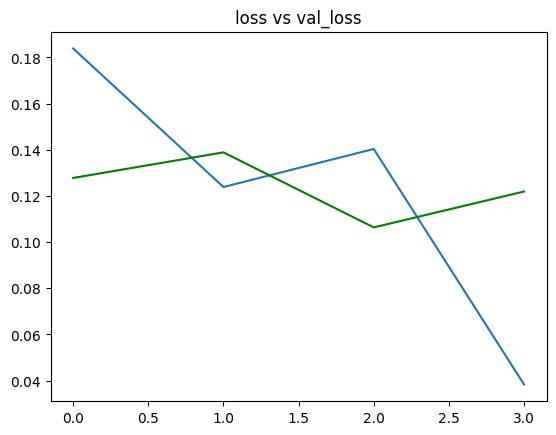

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c='green')
plt.title("loss vs val_loss")
plt.show()

In [ ]:
#model accuracy
from keras.models import load_model

model = load_model("/content/bestmodel.h5")

In [ ]:
# model accuracy
acc = model.evaluate(test_data)[1]

print(f"the accuracy of our model is {acc*100} %")

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9711 - loss: 0.0877
the accuracy of our model is 97.10843563079834 %


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

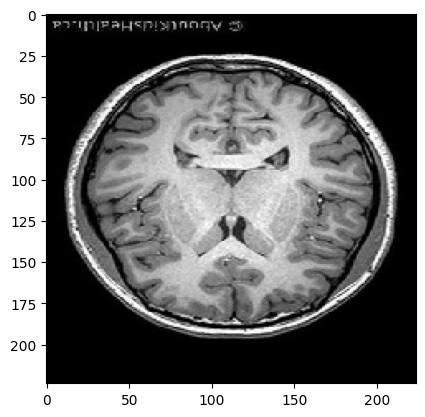

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
The MRI has No Tumour


In [ ]:
path = "/content/Brain Dataset/brain dataset/notumor/Tr-no_286.jpg"

img = load_img(path, target_size=(224,224))
input_arr = img_to_array(img)/255

plt.imshow(input_arr)
plt.show()

input_arr.shape

input_arr = np.expand_dims(input_arr,axis=0)

pred = model.predict(input_arr)[0][0]
pred

if pred > 0.5:
    print("The MRI has Tumour")
else:
    print("The MRI has No Tumour")